# Explore SP accessibility vs. actual travel behavior

In [1]:
%load_ext autoreload
%autoreload 2
%cd D:\netmob25

D:\netmob25


In [ ]:
import os
os.environ['USE_PYGEOS'] = '0'
import pandas as pd
import geopandas as gpd
from statsmodels.stats.weightstats import DescrStatsW
import numpy as np
from tqdm import tqdm
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import libpysal
import esda
import statsmodels.api as sm
import statsmodels.formula.api as smf
import h3.api.numpy_int as h3
from shapely.geometry import Polygon

In [3]:
def weighted_median(data, weights):
    """
    Compute the weighted median of data with given weights.
    """
    data, weights = np.array(data), np.array(weights)
    sorter = np.argsort(data)
    data, weights = data[sorter], weights[sorter]
    cumsum = np.cumsum(weights) / np.sum(weights)
    return data[np.searchsorted(cumsum, 0.5)]

def bootstrap_median(data, weights=None, n_bootstrap=1000, random_state=None):
    """
    Calculate the (weighted) median and its bootstrap standard error.

    Parameters:
    - data: array-like, the dataset from which to sample
    - weights: array-like or None, weights for each data point (default None = unweighted)
    - n_bootstrap: int, number of bootstrap samples
    - random_state: int or None, for reproducibility

    Returns:
    - median_estimate: float, the weighted median of the original data
    - se_median: float, bootstrap standard error of the median
    """
    rng = np.random.default_rng(random_state)
    data = np.array(data)
    
    if weights is None:
        weights = np.ones_like(data, dtype=float)
    else:
        weights = np.array(weights, dtype=float)

    # Original weighted median
    median_estimate = weighted_median(data, weights)

    # Bootstrap
    medians = []
    probs = weights / weights.sum()
    for _ in range(n_bootstrap):
        sample_idx = rng.choice(len(data), size=len(data), replace=True, p=probs)
        medians.append(weighted_median(data[sample_idx], weights[sample_idx]))
    se_median = np.std(medians, ddof=1)

    return median_estimate, se_median

In [4]:
import matplotlib as mpl
def setup_mpl():
    mpl.rc('font', size = 9)
    mpl.rcParams['legend.fontsize'] = 'small'
    mpl.rcParams['legend.fontsize'] = 'small'
    mpl.rcParams['xtick.labelsize'] = 'small'
    mpl.rcParams['ytick.labelsize'] = 'small'
    mpl.rcParams['lines.linewidth'] = 1
    mpl.rcParams['xtick.major.width'] = 1
    mpl.rcParams['ytick.major.width'] = 1
    mpl.rcParams['xtick.minor.width'] = 1
    mpl.rcParams['ytick.minor.width'] = 1
    mpl.rcParams['xtick.major.size'] = 3
    mpl.rcParams['ytick.major.size'] = 3
    mpl.rcParams['xtick.minor.size'] = 1.5
    mpl.rcParams['ytick.minor.size'] = 1.5
    mpl.rcParams['axes.linewidth'] = 1
    mpl.rcParams['xtick.top'] = False
    mpl.rcParams['ytick.right'] = False
    mpl.rcParams['mathtext.default'] = 'regular'
    mpl.rcParams['xtick.major.pad'] = '2.3'
    mpl.rcParams['ytick.major.pad' ]= '2.3'
    mpl.rcParams['axes.labelpad'] = 2

setup_mpl()

## 1. Load data

In [164]:
df_p = pd.read_csv('dbs/data_p/commuter_attributes.csv')
df_a = pd.read_csv('dbs/data_p/commuter_sp_accessibility_r.csv')
df_a['mode'] = df_a['mode'].map({'car': 'Car', 'pt': 'Public transit'})
df_r = pd.read_csv('dbs/data_p/commuter_mobi_efficiency_daily.csv')
print(df_p.columns, '\n', df_a.columns, '\n', df_r.columns, '\n')

Index(['ID', 'time_threshold', 'amenity', 'mode', 'access_h', 'codgeo',
       'weight_ind', 'Gender', 'Age', 'Education', 'Household_type', 'Car_no',
       'Bike_no', 'Two_wheeler_no', 'Escooter_no', 'pt_sub', 'main_mode'],
      dtype='object') 
 Index(['ID', 'mode', 'ak'], dtype='object') 
 Index(['ID', 'date', 'trip_chaining_presence', 'freq_hws', 'xs_total_hws',
       'total_travel_time', 'activity_time_third', 'activity_time_work_study',
       'activity_time_home', 'entropy_naive', 'entropy_mm', 'n_visits',
       'activity_nh_ratio', 'dow', 'day_type', 'weight_day', 'main_mode_day'],
      dtype='object') 



C:\Users\yuanlia\AppData\Local\Temp\ipykernel_14184\1541547419.py:1: DtypeWarning: Columns (13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_p = pd.read_csv('dbs/data_p/commuter_attributes.csv')


In [6]:
df_p.groupby('Household_type')['ID'].nunique().reset_index()

,Household_type,ID
0,0,520
1,1,534
2,2,235
3,3,132
4,4,36
5,5,12
6,6,965
7,7,17


In [7]:
len(df_r.drop_duplicates(subset=['ID', 'date']))

14169

## 2. Individual groups
Car users vs. non-car users (main_mode); Females vs. Males (Gender).

In [8]:
df_p['main_mode'].unique()

array(['Active', 'Private car (driver)', 'Public transit', 'Micro',
       'Private car (passenger)', 'Other', 'Taxi'], dtype=object)

In [206]:
df_p.loc[:, 'main_mode_r'] = df_p['main_mode'].\
    apply(lambda x: 'Car' if x in ['Private car (driver)', 'Private car (passenger)'] else 'Public transit' if x=='Public transit' else 'Active/Micro' if x in ['Active', 'Micro'] else 'Other')

In [166]:
print(df_p.drop_duplicates(subset=['ID'])['Gender'].value_counts())
df_p.drop_duplicates(subset=['ID']).value_counts(['main_mode_r', 'Gender']).sort_index()

Gender
Woman    1347
Man      1104
Name: count, dtype: int64


main_mode_r     Gender
Active/Micro    Man       489
                Woman     485
Car             Man       366
                Woman     548
Other           Man         2
                Woman       1
Public transit  Man       247
                Woman     313
Name: count, dtype: int64

## 3. Efficiency: Travel time vs. activity time

In [167]:
df_r.head()

,ID,date,trip_chaining_presence,freq_hws,xs_total_hws,total_travel_time,activity_time_third,activity_time_work_study,activity_time_home,entropy_naive,entropy_mm,n_visits,activity_nh_ratio,dow,day_type,weight_day,main_mode_day
0,10_2978,2023-03-15,0.0,0.0,0.0,55.0,0.0,0.000000,1385.000000,NaN,NaN,0.0,0.000000,wednesday,Normal,235.905683,PRIV_CAR_DRIVER
1,10_2978,2023-03-16,0.0,0.0,0.0,97.0,0.0,0.000000,1343.000000,NaN,NaN,0.0,0.000000,thursday,Normal,218.345882,PRIV_CAR_DRIVER
2,10_2978,2023-03-17,1.0,1.0,1.0,271.0,0.0,482.016667,686.983333,NaN,NaN,0.0,1.778659,friday,Normal,237.220279,WALKING
3,10_2980,2023-03-13,0.0,0.0,0.0,46.0,0.0,707.533333,686.466667,2.810392,3.089804,34.0,15.381159,monday,Normal,235.626361,SUBWAY
4,10_2980,2023-03-14,0.0,0.0,0.0,69.0,0.0,562.250000,808.750000,2.810392,3.089804,34.0,8.148551,tuesday,Normal,237.524429,ELECT_BIKE


In [168]:
df_r2plot = df_r.groupby("ID").agg({
    "entropy_mm": "first",
    "activity_nh_ratio": lambda x: (x * df_r.loc[x.index, "weight_day"]).sum() / df_r.loc[x.index, "weight_day"].sum(),
    "activity_time_third": lambda x: (x * df_r.loc[x.index, "weight_day"]).sum() / df_r.loc[x.index, "weight_day"].sum(),
    "total_travel_time": lambda x: (x * df_r.loc[x.index, "weight_day"]).sum() / df_r.loc[x.index, "weight_day"].sum(),
    "xs_total_hws": lambda x: (x * df_r.loc[x.index, "weight_day"]).sum() / df_r.loc[x.index, "weight_day"].sum(),
    "trip_chaining_presence": lambda x: 1 if sum(x) > 0 else 0
}).reset_index()
df_r2plot = df_r2plot.fillna(0)
df_r2plot.head()

,ID,entropy_mm,activity_nh_ratio,activity_time_third,total_travel_time,xs_total_hws,trip_chaining_presence
0,10_2978,0.000000,0.610197,0.000000,142.364522,0.343066,1
1,10_2980,3.089804,8.652450,40.620290,45.437880,0.000000,0
2,10_2981,2.904950,1.525254,3.089173,88.080480,0.000000,0
3,10_2982,3.424481,0.506592,21.850490,151.252316,0.142663,1
4,10_2984,3.304250,4.869115,72.831642,56.866288,0.385956,1


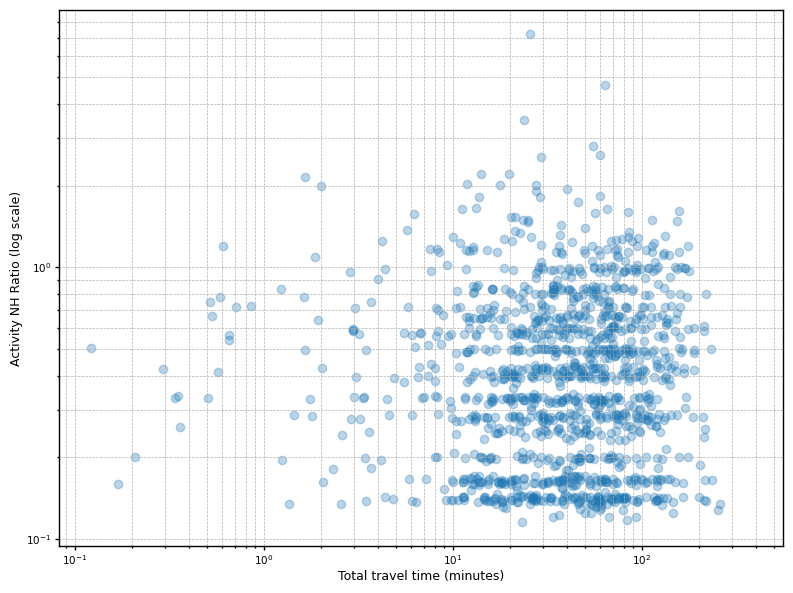

In [169]:
plt.figure(figsize=(8, 6))
plt.scatter(df_r2plot["activity_time_third"], df_r2plot["xs_total_hws"], alpha=0.3)

plt.xlabel("Total travel time (minutes)")
plt.ylabel("Activity NH Ratio (log scale)")
plt.yscale("log")  # <-- log transform
plt.xscale("log")  # <-- log transform
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### 2.1 Efficiency vs. diversity

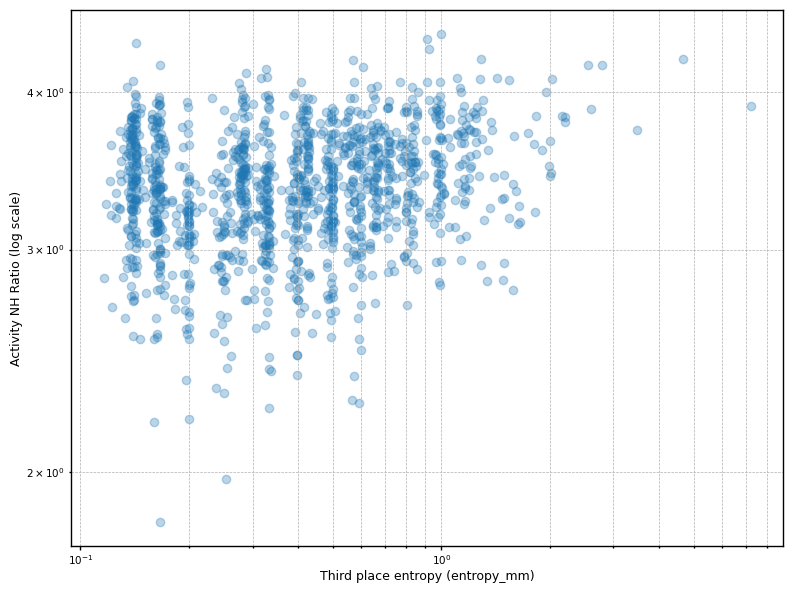

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(df_r2plot["xs_total_hws"], df_r2plot["entropy_mm"], alpha=0.3)

plt.xlabel("Third place entropy (entropy_mm)")
plt.ylabel("Activity NH Ratio (log scale)")
plt.yscale("log")  # <-- log transform
plt.xscale("log")  # <-- log transform
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### 2.2 Group differences

In [170]:
df_r2plot = df_r2plot.merge(df_p.drop_duplicates(subset=['ID'])[['Gender', 'main_mode_r', 'ID', 'Age', 'Education', 'Household_type', 'weight_ind']], on='ID', how='left')

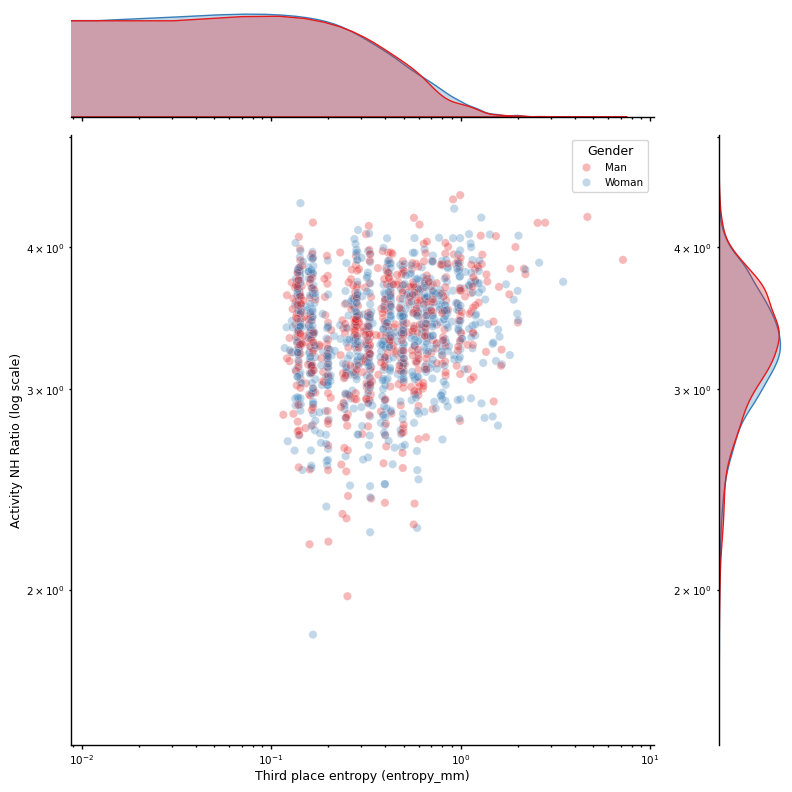

In [171]:
# Make sure your Gender column is categorical for coloring
df_r2plot["main_mode_r"] = df_r2plot["main_mode_r"].astype("category")

# Jointplot with scatter and KDE marginals
g = sns.jointplot(
    data=df_r2plot[(df_r2plot["main_mode_r"] != "Other") & (df_r2plot["entropy_mm"] > 0.01)],
    y="entropy_mm",
    x="xs_total_hws",
    hue="Gender",
    kind="scatter",
    marginal_kws=dict(common_norm=False, fill=True, alpha=0.3),
    palette="Set1",
    height=8,
    alpha=0.3
)

# Set log-log axes
g.ax_joint.set_xscale("log")
g.ax_joint.set_yscale("log")

# Axis labels
g.set_axis_labels("Third place entropy (entropy_mm)", "Activity NH Ratio (log scale)")

plt.tight_layout()
plt.show()

## 4. Space-time accessibility

In [172]:
df_a.head()

,ID,mode,ak
0,10_2978,Public transit,0
1,10_2978,Car,6528
2,10_2980,Public transit,10934
3,10_2980,Car,21405
4,10_2981,Public transit,0


In [173]:
df_r2plot = df_r2plot.merge(df_p.loc[(df_p['time_threshold'] == '30 min') & (df_p['amenity'] == 'Social & Leisure'), 
                                     ['ID', 'access_h', 'mode']], on='ID', how='left')
df_r2plot.head()

,ID,entropy_mm,activity_nh_ratio,activity_time_third,total_travel_time,xs_total_hws,trip_chaining_presence,Gender,main_mode_r,Age,Education,Household_type,weight_ind,access_h,mode
0,10_2978,0.000000,0.610197,0.000000,142.364522,0.343066,1,Woman,Active/Micro,41.0,9.0,6.0,1856.206160,18158.5,Car
1,10_2978,0.000000,0.610197,0.000000,142.364522,0.343066,1,Woman,Active/Micro,41.0,9.0,6.0,1856.206160,192.0,Public transit
2,10_2980,3.089804,8.652450,40.620290,45.437880,0.000000,0,Man,Active/Micro,30.0,5.0,0.0,1375.000372,30535.0,Car
3,10_2980,3.089804,8.652450,40.620290,45.437880,0.000000,0,Man,Active/Micro,30.0,5.0,0.0,1375.000372,4283.0,Public transit
4,10_2981,2.904950,1.525254,3.089173,88.080480,0.000000,0,Man,Active/Micro,38.0,5.0,1.0,1231.812990,12534.0,Car


In [174]:
# Step 1: get IDs where main_mode_r is "Car"
car_ids = df_r2plot.loc[df_r2plot["main_mode_r"] == "Car", "ID"].unique()

# Step 2: filter
df_filtered = df_r2plot[
    ((df_r2plot["ID"].isin(car_ids)) & (df_r2plot["main_mode_r"] == df_r2plot["mode"])) |
    ((~df_r2plot["ID"].isin(car_ids)) & (df_r2plot["mode"] != "Car"))
]
df_filtered.head()

,ID,entropy_mm,activity_nh_ratio,activity_time_third,total_travel_time,xs_total_hws,trip_chaining_presence,Gender,main_mode_r,Age,Education,Household_type,weight_ind,access_h,mode
1,10_2978,0.000000,0.610197,0.000000,142.364522,0.343066,1,Woman,Active/Micro,41.0,9.0,6.0,1856.206160,192.0,Public transit
3,10_2980,3.089804,8.652450,40.620290,45.437880,0.000000,0,Man,Active/Micro,30.0,5.0,0.0,1375.000372,4283.0,Public transit
5,10_2981,2.904950,1.525254,3.089173,88.080480,0.000000,0,Man,Active/Micro,38.0,5.0,1.0,1231.812990,180.0,Public transit
6,10_2982,3.424481,0.506592,21.850490,151.252316,0.142663,1,Man,Car,43.0,4.0,2.0,426.311616,3092.0,Car
8,10_2984,3.304250,4.869115,72.831642,56.866288,0.385956,1,Woman,Car,39.0,5.0,0.0,843.194726,11523.0,Car


In [175]:
df_filtered = df_filtered.merge(df_a, on=['ID', 'mode'], how='left')
df_filtered.head()

,ID,entropy_mm,activity_nh_ratio,activity_time_third,total_travel_time,xs_total_hws,trip_chaining_presence,Gender,main_mode_r,Age,Education,Household_type,weight_ind,access_h,mode,ak
0,10_2978,0.000000,0.610197,0.000000,142.364522,0.343066,1,Woman,Active/Micro,41.0,9.0,6.0,1856.206160,192.0,Public transit,0.0
1,10_2980,3.089804,8.652450,40.620290,45.437880,0.000000,0,Man,Active/Micro,30.0,5.0,0.0,1375.000372,4283.0,Public transit,10934.0
2,10_2981,2.904950,1.525254,3.089173,88.080480,0.000000,0,Man,Active/Micro,38.0,5.0,1.0,1231.812990,180.0,Public transit,0.0
3,10_2982,3.424481,0.506592,21.850490,151.252316,0.142663,1,Man,Car,43.0,4.0,2.0,426.311616,3092.0,Car,0.0
4,10_2984,3.304250,4.869115,72.831642,56.866288,0.385956,1,Woman,Car,39.0,5.0,0.0,843.194726,11523.0,Car,7411.0


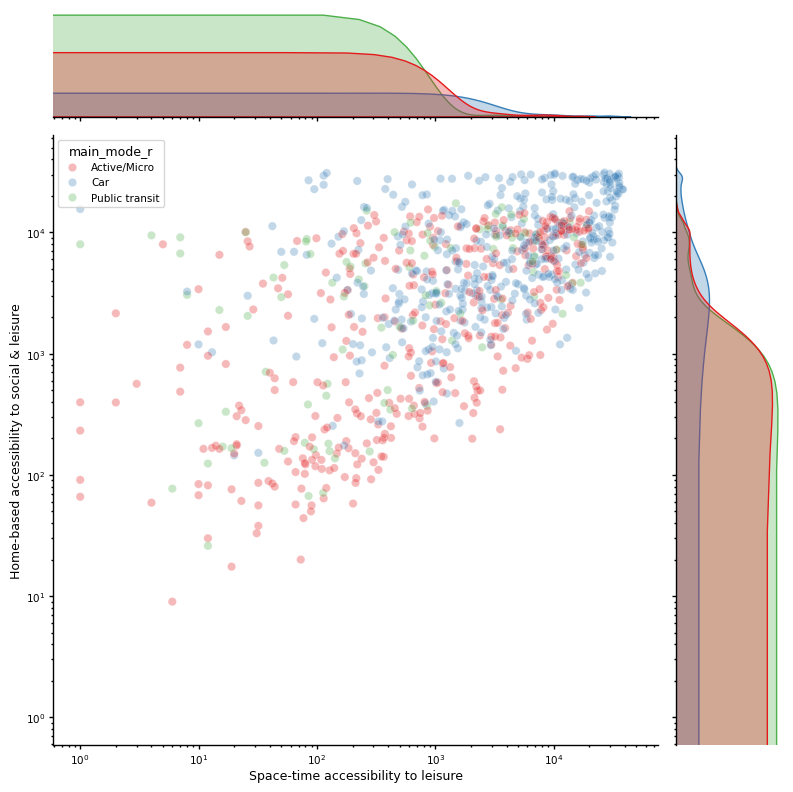

In [207]:
# Make sure your Gender column is categorical for coloring
# df_filtered["situation"] = df_filtered["situation"].astype("category")

# Jointplot with scatter and KDE marginals
g = sns.jointplot(
    data=df_filtered,
    x="ak",
    y="access_h",
    hue="main_mode_r",
    kind="scatter",
    marginal_kws=dict(common_norm=False, fill=True, alpha=0.3),
    palette="Set1",
    height=8,
    alpha=0.3
)

# Set log-log axes
g.ax_joint.set_xscale("log")
g.ax_joint.set_yscale("log")

# Axis labels
g.set_axis_labels("Space-time accessibility to leisure", "Home-based accessibility to social & leisure")

plt.tight_layout()
plt.show()

In [177]:
df_filtered.iloc[0]

ID                               10_2978
entropy_mm                           0.0
activity_nh_ratio               0.610197
activity_time_third                  0.0
total_travel_time             142.364522
xs_total_hws                    0.343066
trip_chaining_presence                 1
Gender                             Woman
main_mode_r                 Active/Micro
Age                                 41.0
Education                            9.0
Household_type                       6.0
weight_ind                    1856.20616
access_h                           192.0
mode                      Public transit
ak                                   0.0
Name: 0, dtype: object

In [178]:
df_filtered.loc[:, 'ak_cat'] = df_filtered['ak'].apply(lambda x: 'Zero' if x == 0 else 'Non-zero')
df_filtered = df_filtered[df_filtered['main_mode_r'] != 'Other'].copy()

In [179]:
df_filtered["main_mode_r"] = df_filtered["main_mode_r"].astype("category")
df_filtered.groupby(['ak_cat', 'main_mode_r']).agg({
    'ID': 'count',  # Count of IDs
    'entropy_mm': 'mean',  # Mean of entropy_mm
    'activity_time_third': 'mean',  # Mean
    'access_h': 'mean',  # Mean of access_h
    'xs_total_hws': 'mean',
    'ak': 'mean',  # Mean of ak
    'trip_chaining_presence': 'sum'
}).reset_index().sort_values(by=['ak_cat', 'main_mode_r'])

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_14184\2727805424.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby(['ak_cat', 'main_mode_r']).agg({


,ak_cat,main_mode_r,ID,entropy_mm,activity_time_third,access_h,xs_total_hws,ak,trip_chaining_presence
0,Non-zero,Active/Micro,392,2.630641,44.954258,4149.605867,0.348434,3290.380102,294
1,Non-zero,Car,425,2.390153,30.916306,10201.235294,0.420292,8758.712941,310
2,Non-zero,Other,0,NaN,NaN,NaN,NaN,NaN,0
3,Non-zero,Public transit,103,2.205446,48.369212,5269.402913,0.340172,2732.737864,73
4,Zero,Active/Micro,581,2.687859,37.178442,2366.152324,0.285618,0.000000,372
5,Zero,Car,489,2.335608,31.663403,8072.196319,0.390303,0.000000,353
6,Zero,Other,0,NaN,NaN,NaN,NaN,NaN,0
7,Zero,Public transit,454,2.103162,33.535251,2021.066079,0.303155,0.000000,313


In [180]:
df_filtered.loc[:, 'ak_log'] = df_filtered['ak'].apply(lambda x: np.log(x) if x > 0 else 0)

In [181]:
df_filtered.columns

Index(['ID', 'entropy_mm', 'activity_nh_ratio', 'activity_time_third',
       'total_travel_time', 'xs_total_hws', 'trip_chaining_presence', 'Gender',
       'main_mode_r', 'Age', 'Education', 'Household_type', 'weight_ind',
       'access_h', 'mode', 'ak', 'ak_cat', 'ak_log'],
      dtype='object')

In [65]:

# ----- 1. Effect on entropy_mm -----
model_entropy = smf.ols(
    formula="entropy_mm ~ ak_log + C(Gender) + C(mode) + Age + C(Education) + C(Household_type)",
    data=df_filtered
).fit(weights=df_filtered["weight_ind"])

print("\n--- Entropy_mm model (weighted) ---")
print(model_entropy.summary())


--- Entropy_mm model (weighted) ---
                            OLS Regression Results                            
Dep. Variable:             entropy_mm   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     6.583
Date:                Thu, 28 Aug 2025   Prob (F-statistic):           1.35e-15
Time:                        12:09:27   Log-Likelihood:                -4408.3
No. Observations:                2444   AIC:                             8853.
Df Residuals:                    2426   BIC:                             8957.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In [299]:
# ----- 2. Effect on activity_nh_ratio -----
model_activity = smf.ols(
    formula="activity_time_third ~ ak_log + Gender + C(mode)",
    data=df_filtered
).fit()

print("\n--- Activity_nh_ratio model ---")
print(model_activity.summary())


--- Activity_nh_ratio model ---
                             OLS Regression Results                            
Dep. Variable:     activity_time_third   R-squared:                       0.041
Model:                             OLS   Adj. R-squared:                  0.040
Method:                  Least Squares   F-statistic:                     34.54
Date:                 Fri, 22 Aug 2025   Prob (F-statistic):           7.35e-22
Time:                         18:42:37   Log-Likelihood:                -14072.
No. Observations:                 2444   AIC:                         2.815e+04
Df Residuals:                     2440   BIC:                         2.818e+04
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

In [300]:
# ----- 3. Effect on trip_chaining complexity -----
model_activity = smf.ols(
    formula="xs_total_hws ~ ak_log + Gender + C(mode)",
    data=df_filtered
).fit()

print("\n--- Trip_chaining complexity model ---")
print(model_activity.summary())


--- Trip_chaining complexity model ---
                            OLS Regression Results                            
Dep. Variable:           xs_total_hws   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     39.86
Date:                Fri, 22 Aug 2025   Prob (F-statistic):           3.86e-25
Time:                        18:42:42   Log-Likelihood:                -1291.0
No. Observations:                2444   AIC:                             2590.
Df Residuals:                    2440   BIC:                             2613.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

## 5 Prepare data for visualization (Figure 2)

In [182]:
df_filtered.columns

Index(['ID', 'entropy_mm', 'activity_nh_ratio', 'activity_time_third',
       'total_travel_time', 'xs_total_hws', 'trip_chaining_presence', 'Gender',
       'main_mode_r', 'Age', 'Education', 'Household_type', 'weight_ind',
       'access_h', 'mode', 'ak', 'ak_cat', 'ak_log'],
      dtype='object')

In [183]:
df_filtered = df_filtered.merge(df_p[['ID', 'codgeo', 'pt_sub']].drop_duplicates(subset=['ID']), on='ID', how='left')

In [184]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_filtered['entropy_mm_norm'] = scaler.fit_transform(df_filtered[['entropy_mm']])

In [185]:
# access_col: the column to bin
# step: 0.5 → boundaries at 10^0, 10^0.5, 10^1, ...
def assign_log_bins(df, access_col, step=0.5):
    s = df[access_col].astype(float)

    # Ignore non-positive values for log binning (they'll become NaN groups)
    pos = s[s > 0]
    if pos.empty:
        df['grp_cell'] = np.nan
        return df

    # Build log10-spaced edges covering the data
    lo = np.floor(np.log10(pos.min()) / step) * step
    hi = np.ceil(np.log10(pos.max()) / step) * step
    edges = 10 ** np.arange(lo, hi + step, step)

    # Cut using those edges; label groups 1..K
    labels = range(1, len(edges))
    df['grp_cell'] = pd.cut(s, bins=edges, labels=labels, include_lowest=True)

    # Optional: make it float like your original
    df['grp_cell'] = df['grp_cell'].astype(float)
    return df


def assign_quantile_bins(data, access_col='access_h', num_grp=None):
    data.loc[:, 'grp_cell'] = pd.qcut(data.loc[:, access_col], q=num_grp, labels=[i for i in range(1, num_grp + 1)])
    data.loc[:, 'grp_cell'] = data.loc[:, 'grp_cell'].astype(float)
    return data

In [186]:
def access_vs_y(df=None, num_grp=None, access_col='access_h', step=0.4):
    df = pd.concat([assign_quantile_bins(df_filtered[(df_filtered[access_col] > 0) & (df_filtered['mode'] == 'Car')], access_col=access_col, num_grp=num_grp),
                   assign_quantile_bins(df_filtered[(df_filtered[access_col] > 0) & (df_filtered['mode'] == 'Public transit')], access_col=access_col, num_grp=num_grp)])
    #df = pd.concat([assign_log_bins(df_filtered[(df_filtered[access_col] > 0) & (df_filtered['mode'] == 'Car')], access_col=access_col, step=step),
    #                assign_log_bins(df_filtered[(df_filtered[access_col] > 0) & (df_filtered['mode'] == 'Public transit')], access_col=access_col, step=step)])
    def grp_stats(data):
        md_e, md_err_e = bootstrap_median(data["entropy_mm_norm"], weights=data['weight_ind'], n_bootstrap=1000)
        md_t, md_err_t = bootstrap_median(data["xs_total_hws"], weights=data['weight_ind'], n_bootstrap=1000)
        md_a, md_err_a = bootstrap_median(data["activity_time_third"], weights=data['weight_ind'], n_bootstrap=1000)
        share = data.loc[data['trip_chaining_presence'] == 1, 'weight_ind'].sum() / data['weight_ind'].sum()
        return pd.Series(dict(r=data[access_col].median(),
                              entropy_mm_norm_50=md_e,
                              entropy_mm_norm_err=md_err_e,
                              activity_time_third_50=md_a,
                              activity_time_third_err=md_err_a,
                              xs_total_hws_50=md_t,
                              xs_total_hws_err=md_err_t,
                              trip_chaining_presence_50=share,
                              trip_chaining_presence_err=0))
    df_g = df.groupby(['grp_cell', 'mode'], observed=True).apply(grp_stats, include_groups=False).reset_index()
    return df_g

In [129]:
df_ak_g = access_vs_y(df=df_filtered[df_filtered['ak'] > 0], num_grp=15, access_col='ak')
df_ak_g.loc[:, 'a_type'] = 'Space-time accessibility to leisure'
df_ah_g = access_vs_y(df=df_filtered[df_filtered['access_h'] > 0], num_grp=15, access_col='access_h')
df_ah_g.loc[:, 'a_type'] = 'Home-based accessibility to social & leisure'
df_ag = pd.concat([df_ak_g, df_ah_g], ignore_index=True)
df_ag.head()

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_14184\2884506554.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'grp_cell'] = pd.qcut(data.loc[:, access_col], q=num_grp, labels=[i for i in range(1, num_grp + 1)])
C:\Users\yuanlia\AppData\Local\Temp\ipykernel_14184\2884506554.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'grp_cell'] = pd.qcut(data.loc[:, access_col], q=num_grp, labels=[i for i in range(1, num_grp + 1)])
C:\Users\yuanlia\AppData\Local\Temp\ipykernel_14184\28

,grp_cell,mode,r,entropy_mm_norm_50,entropy_mm_norm_err,activity_time_third_50,activity_time_third_err,xs_total_hws_50,xs_total_hws_err,trip_chaining_presence_50,trip_chaining_presence_err,a_type
0,1,Car,95.0,0.723048,0.028676,20.391170,42.405080,0.427524,0.191283,0.784045,0.0,Space-time accessibility to leisure
1,1,Public transit,8.0,0.679447,0.044494,0.000000,0.000000,0.249998,0.017860,0.783469,0.0,Space-time accessibility to leisure
2,2,Car,289.0,0.688833,0.123860,18.092691,6.957220,0.284541,0.127976,0.772995,0.0,Space-time accessibility to leisure
3,2,Public transit,25.0,0.638822,0.035331,17.008508,2.184712,0.000000,0.009720,0.388561,0.0,Space-time accessibility to leisure
4,3,Car,591.0,0.644877,0.284828,7.213453,3.438396,0.169879,0.126205,0.679181,0.0,Space-time accessibility to leisure


In [92]:
def access_impact_plot(df_b=None, y='diversity', ylb=None):
    fig, axes = plt.subplots(1, 2, figsize=(4, 2), dpi=300, sharey=True)

    # --- Helper to plot errorbars + fit line for a subset ---
    def plot_with_fit(ax, df_sub, title, color):
        x = df_sub["r"].to_numpy(dtype=float)
        y50 = df_sub[f"{y}_50"].to_numpy(dtype=float)
        yerr = df_sub[f"{y}_err"].to_numpy(dtype=float)

        # Error bars
        ax.errorbar(
            x, y50,
            yerr=[yerr, yerr],
            fmt='o',
            capsize=2,
            color=color,
            markersize=4
        )

        # ----- Fit y ~ a*log10(x) + b -----
        mask = np.isfinite(x) & (x > 0) & np.isfinite(y50)
        if mask.sum() >= 2:
            x_fit = x[mask]
            y_fit = y50[mask]
            logx = np.log10(x_fit)
            m, b = np.polyfit(logx, y_fit, deg=1)

            xs = np.geomspace(x_fit.min(), x_fit.max(), 200)
            ys = m * np.log10(xs) + b
            ax.plot(xs, ys, color=color, lw=0.7, alpha=0.7)

        ax.set_xscale("log")
        ax.set_xlabel("Accessibility")
        ax.set_title(title, fontsize=10, loc="left")
        sns.despine(ax=ax)

    # --- Car (left plot) ---
    data1 = df_b[df_b['mode'] == 'Car'].copy()
    plot_with_fit(axes[0], data1, title="Car", color="#0fbcf9")

    # --- Public transit (right plot) ---
    data2 = df_b[df_b['mode'] == 'Public transit'].copy()
    plot_with_fit(axes[1], data2, title="Public transit", color="#05c46b")

    # Shared y-axis label
    axes[0].set_ylabel(ylb)

    plt.tight_layout()
    return fig, axes

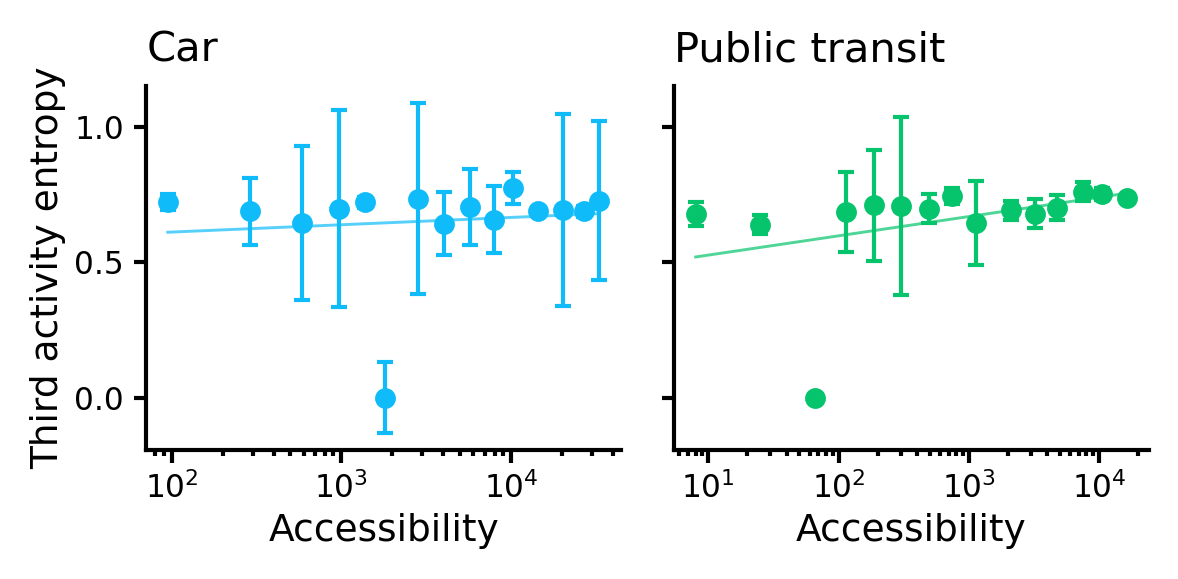

In [130]:
fig, _ = access_impact_plot(df_b=df_ag[df_ag['a_type'] == 'Space-time accessibility to leisure'], y='entropy_mm_norm', ylb="Third activity entropy")
fig.savefig("figures/entropy_mm.png", dpi=300, bbox_inches='tight')

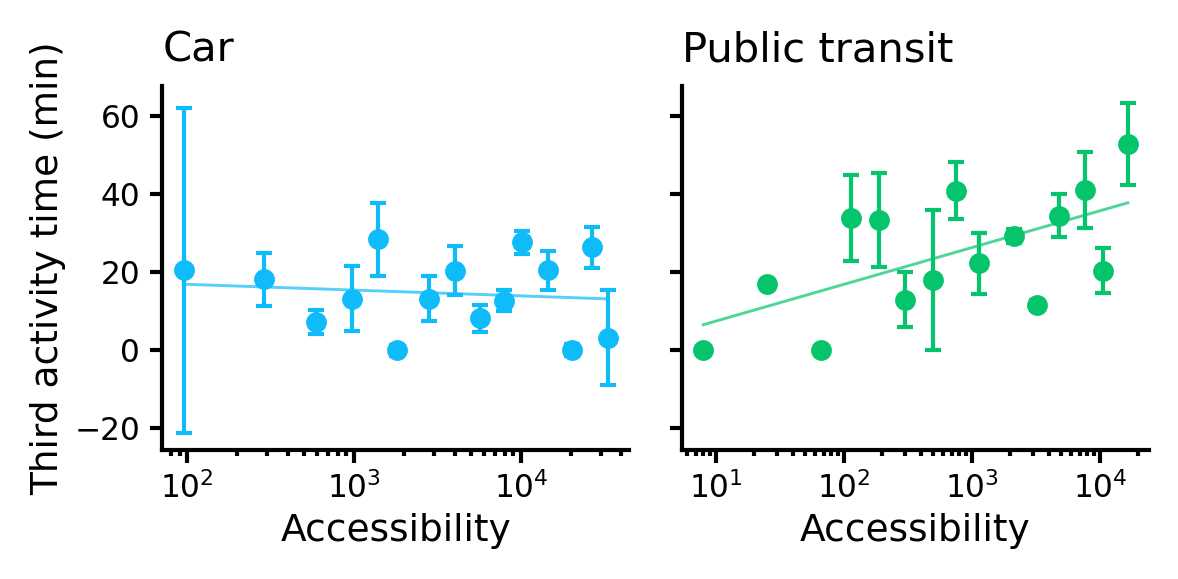

In [116]:
fig, _ = access_impact_plot(df_b=df_ag[df_ag['a_type'] == 'Space-time accessibility to leisure'], y='activity_time_third', ylb="Third activity time (min)")
fig.savefig("figures/activity_time_third.png", dpi=300, bbox_inches='tight')

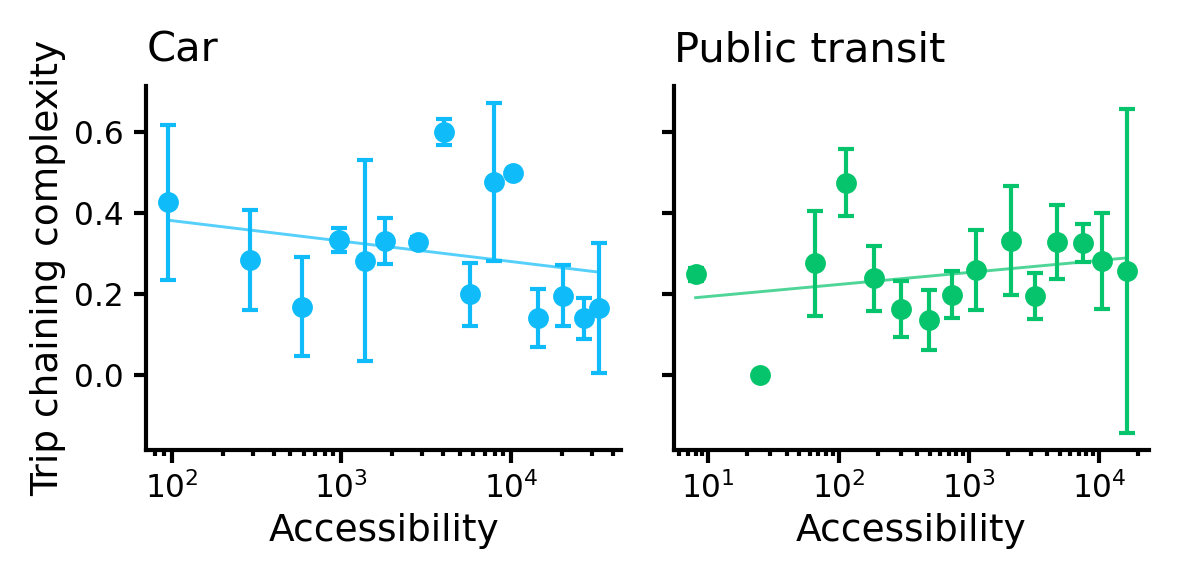

In [117]:
fig, _ = access_impact_plot(df_b=df_ag[df_ag['a_type'] == 'Space-time accessibility to leisure'], y='xs_total_hws', ylb="Trip chaining complexity")
fig.savefig("figures/xs_total_hws.png", dpi=300, bbox_inches='tight')

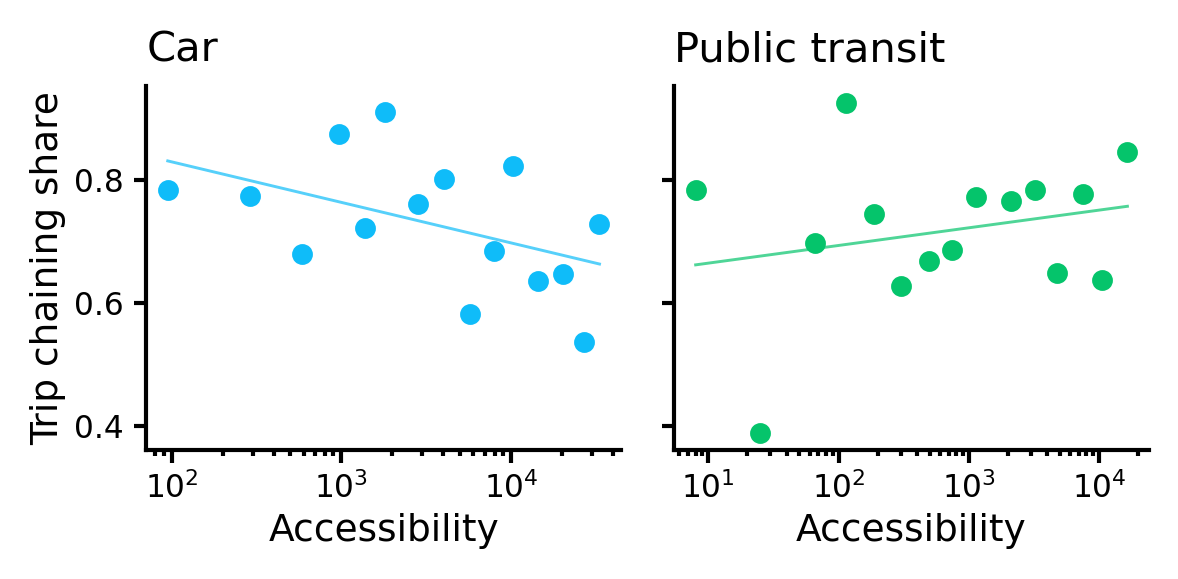

In [118]:
fig, _ = access_impact_plot(df_b=df_ag[df_ag['a_type'] == 'Space-time accessibility to leisure'], y='trip_chaining_presence', ylb="Trip chaining share")
fig.savefig("figures/trip_chaining_presence.png", dpi=300, bbox_inches='tight')

### 5.1 SPA zero vs. non zero

In [131]:
def ak_cat_agg(data=None):
    trip_chaining_presence = data.loc[data['trip_chaining_presence'] == 1, 'weight_ind'].sum() / data['weight_ind'].sum() * 100
    md_e, md_err_e = bootstrap_median(data["entropy_mm_norm"], weights=data['weight_ind'], n_bootstrap=1000)
    md_t, md_err_t = bootstrap_median(data["xs_total_hws"], weights=data['weight_ind'], n_bootstrap=1000)
    md_a, md_err_a = bootstrap_median(data["activity_time_third"], weights=data['weight_ind'], n_bootstrap=1000)
    return pd.Series(dict(entropy_mm_norm_50=md_e,
                          entropy_mm_norm_err=md_err_e,
                          activity_time_third_50=md_a,
                          activity_time_third_err=md_err_a,
                          xs_total_hws_50=md_t,
                          xs_total_hws_err=md_err_t,
                          trip_chaining_presence_50=trip_chaining_presence,
                          trip_chaining_presence_err=0))

df_chain_presence = df_filtered.groupby(['ak_cat', 'mode']).apply(ak_cat_agg).reset_index()
df_chain_presence.head()

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_14184\1346945616.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_chain_presence = df_filtered.groupby(['ak_cat', 'mode']).apply(ak_cat_agg).reset_index()


,ak_cat,mode,entropy_mm_norm_50,entropy_mm_norm_err,activity_time_third_50,activity_time_third_err,xs_total_hws_50,xs_total_hws_err,trip_chaining_presence_50,trip_chaining_presence_err
0,Non-zero,Car,0.694072,0.011422,13.766176,2.580123,0.282572,0.033015,72.517107,0.0
1,Non-zero,Public transit,0.704214,0.014508,25.583142,2.152312,0.265069,0.015965,72.095803,0.0
2,Zero,Car,0.702302,0.045867,10.571429,2.799138,0.308759,0.032918,72.611341,0.0
3,Zero,Public transit,0.678825,0.043070,13.327924,0.602768,0.166235,0.004735,63.974168,0.0


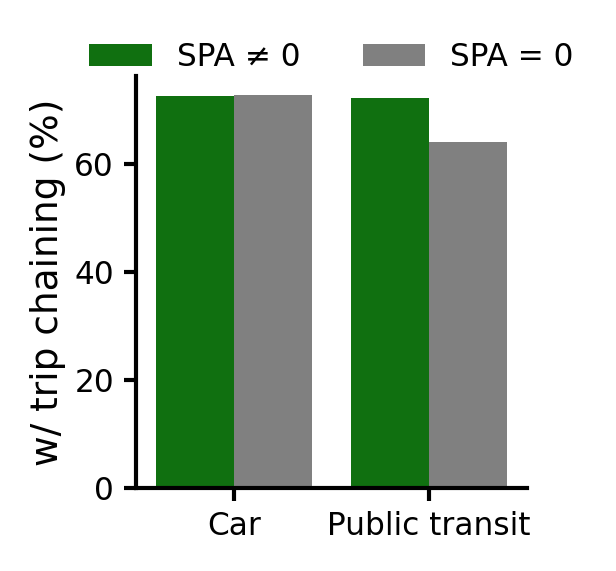

In [132]:
# Map to SPA groups
df_chain_presence["SPA"] = df_chain_presence["ak_cat"].map({"Zero": "SPA = 0"}).fillna("SPA ≠ 0")

# 2×2 pivot
heat = (
    df_chain_presence.pivot(index="SPA", columns="mode", values="trip_chaining_presence_50")
      .reindex(index=["SPA = 0", "SPA ≠ 0"], columns=["Car", "Public transit"])
)

# Plot grouped bar chart
fig, ax = plt.subplots(1, 1, figsize=(2, 2), dpi=300, sharey=True)
ax = sns.barplot(
    data=df_chain_presence,
    x="mode",
    y="trip_chaining_presence_50",
    hue="SPA",
    palette={"SPA = 0": "gray", "SPA ≠ 0": "green"}
)

# Labels and title
ax.set_ylabel("w/ trip chaining (%)")
ax.set_xlabel("")
# ax.set_title("Trip-chaining presence by SPA and mode", loc="left", fontsize=10)
ax.legend(
    title="",
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=2
)
sns.despine()

plt.tight_layout()
fig.savefig("figures/trip_chaining_presence_spa.png", dpi=300, bbox_inches='tight')
plt.show()

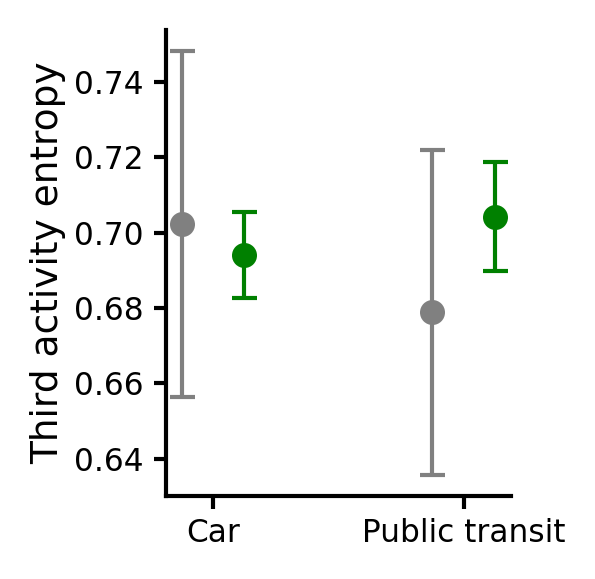

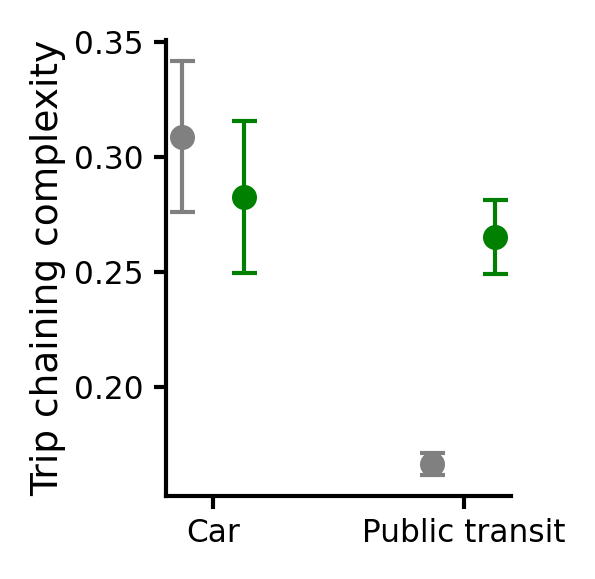

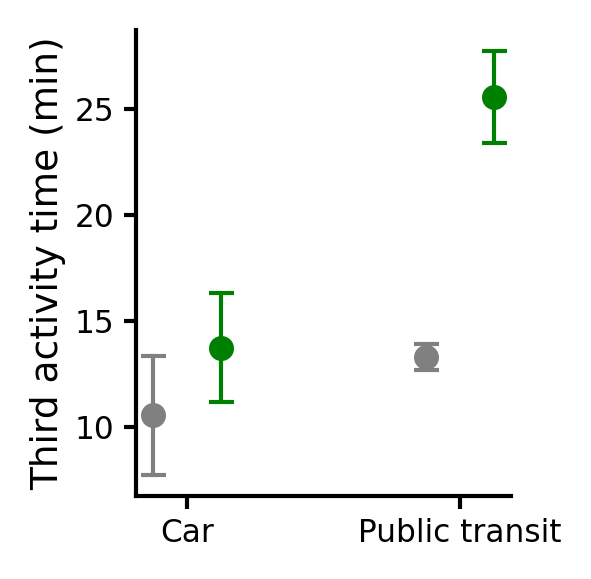

In [134]:
def entropy_errplot_combined(df, ylabel="Entropy (median ± SE)", var='entropy_mm'):
    # expected columns: ak_cat ∈ {'Zero','Non-zero'}, mode ∈ {'Car','Public transit'},
    #                   entropy_mm_50, entropy_mm_err
    mode_order = ['Car', 'Public transit']
    spa_order  = ['Zero', 'Non-zero']
    colors = {'Zero': 'gray', 'Non-zero': 'green'}

    fig, ax = plt.subplots(figsize=(2, 2), dpi=300)

    # Positioning: offset SPA within each mode
    width = 0.25
    x = np.arange(len(mode_order))  # positions for Car/PT

    for j, spa in enumerate(spa_order):
        sub = df[df['ak_cat'] == spa].copy()
        means = [sub.loc[sub['mode'] == m, f'{var}_50'].values[0] for m in mode_order]
        errs  = [sub.loc[sub['mode'] == m, f'{var}_err'].values[0] for m in mode_order]

        ax.errorbar(
            x + (j-0.5)*width, means,
            yerr=errs,
            fmt='o', ms=5, capsize=3,
            color=colors[spa],
            label=f"SPA={spa}"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(mode_order)
    ax.set_ylabel(ylabel)
    sns.despine(ax=ax)

    # Legend horizontal on top
    handles, labels = ax.get_legend_handles_labels()
    #ax.legend(handles, labels, title="", frameon=False,
    #          loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=2)

    plt.tight_layout()
    return fig, ax

# Usage
fig, _ = entropy_errplot_combined(df_chain_presence, ylabel="Third activity entropy", var='entropy_mm_norm')
fig.savefig("figures/entropy_mm_spa.png", dpi=300, bbox_inches='tight')
plt.show()
fig, _ = entropy_errplot_combined(df_chain_presence, ylabel="Trip chaining complexity", var='xs_total_hws')
fig.savefig("figures/xs_total_hws_spa.png", dpi=300, bbox_inches='tight')
plt.show()
fig, _ = entropy_errplot_combined(df_chain_presence, ylabel="Third activity time (min)", var='activity_time_third')
fig.savefig("figures/activity_time_third_spa.png", dpi=300, bbox_inches='tight')
plt.show()

In [213]:
df_filtered.loc[:, 'active_mode'] = df_filtered.loc[:, 'main_mode_r'].apply(lambda x: 1 if x == "Active/Micro" else 0)
df_filtered.head()

,ID,entropy_mm,activity_nh_ratio,activity_time_third,total_travel_time,xs_total_hws,trip_chaining_presence,Gender,main_mode_r,Age,...,mode,ak,ak_cat,ak_log,codgeo,pt_sub,entropy_mm_norm,id,h3_id,active_mode
0,10_2978,0.000000,0.610197,0.000000,142.364522,0.343066,1,Woman,Active/Micro,41.0,...,Public transit,0.0,Zero,0.000000,78092.0,False,0.000000,10_2978,608543703392321535,1
1,10_2980,3.089804,8.652450,40.620290,45.437880,0.000000,0,Man,Active/Micro,30.0,...,Public transit,10934.0,Non-zero,9.299632,75120.0,True,0.695350,10_2980,608543704398954495,1
2,10_2981,2.904950,1.525254,3.089173,88.080480,0.000000,0,Man,Active/Micro,38.0,...,Public transit,0.0,Zero,0.000000,91326.0,True,0.653749,10_2981,608543706177339391,1
3,10_2982,3.424481,0.506592,21.850490,151.252316,0.142663,1,Man,Car,43.0,...,Car,0.0,Zero,0.000000,91573.0,True,0.770667,10_2982,608543459686481919,0
4,10_2984,3.304250,4.869115,72.831642,56.866288,0.385956,1,Woman,Car,39.0,...,Car,7411.0,Non-zero,8.910721,78073.0,True,0.743610,10_2984,608543709398564863,0


In [214]:
df_filtered.dropna(inplace=True)
print(len(df_filtered))
df_filtered.to_csv('dbs/data_p/commuter_model_features_r.csv', index=False)

2444


### 5.2 Heatmap

In [188]:
# --- 2. Variables to plot ---
y_vars = ['entropy_mm_norm', 'activity_time_third', 'xs_total_hws']
df2plot = df_filtered.copy()
# --- 3. Loop over y variables ---
for y in y_vars:
    plt.figure(figsize=(5,4), dpi=300)
    
    # Create 2D heatmap using hexbin (better for continuous data) or hist2d
    hb = plt.hexbin(
        df2plot['ak_log'], df2plot[y],
        gridsize=25, cmap="viridis", bins='log'
    )
    
    plt.colorbar(hb, label="Counts (log scale)")
    plt.xlabel("ak_log")
    plt.ylabel(y)
    plt.title(f"2D heatmap: ak_log vs {y}")
    
    # Save
    fname = f"figures/heatmap_{y}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved {fname}")

Saved figures/heatmap_entropy_mm_norm.png
Saved figures/heatmap_activity_time_third.png
Saved figures/heatmap_xs_total_hws.png


In [189]:
df_filtered.head()

,ID,entropy_mm,activity_nh_ratio,activity_time_third,total_travel_time,xs_total_hws,trip_chaining_presence,Gender,main_mode_r,Age,...,Household_type,weight_ind,access_h,mode,ak,ak_cat,ak_log,codgeo,pt_sub,entropy_mm_norm
0,10_2978,0.000000,0.610197,0.000000,142.364522,0.343066,1,Woman,Active/Micro,41.0,...,6.0,1856.206160,192.0,Public transit,0.0,Zero,0.000000,78092.0,False,0.000000
1,10_2980,3.089804,8.652450,40.620290,45.437880,0.000000,0,Man,Active/Micro,30.0,...,0.0,1375.000372,4283.0,Public transit,10934.0,Non-zero,9.299632,75120.0,True,0.695350
2,10_2981,2.904950,1.525254,3.089173,88.080480,0.000000,0,Man,Active/Micro,38.0,...,1.0,1231.812990,180.0,Public transit,0.0,Zero,0.000000,91326.0,True,0.653749
3,10_2982,3.424481,0.506592,21.850490,151.252316,0.142663,1,Man,Car,43.0,...,2.0,426.311616,3092.0,Car,0.0,Zero,0.000000,91573.0,True,0.770667
4,10_2984,3.304250,4.869115,72.831642,56.866288,0.385956,1,Woman,Car,39.0,...,0.0,843.194726,11523.0,Car,7411.0,Non-zero,8.910721,78073.0,True,0.743610


## 6. SPA on the map

In [190]:
df_filtered = pd.read_csv('dbs/data_p/commuter_model_features_r.csv')

Calculating H3 IDs: 100%|██████████| 2382/2382 [00:00<00:00, 74470.64it/s]


<Axes: >

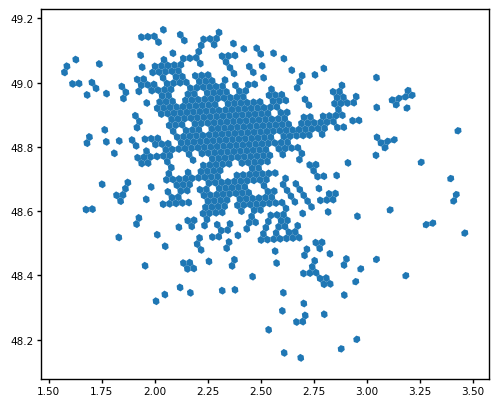

In [200]:
df_work = pd.read_csv('dbs/data_p/commuter_trips.csv')
df_work = df_work[df_work['purpose_d'] == 'HOME'].copy()
df_work.drop_duplicates(subset=['ID'], inplace=True)
df_work = df_work[['ID', 'end_lon', 'end_lat']].rename(columns={'ID': 'id', 'end_lon': 'lon', 'end_lat': 'lat'})
# Concatenate and drop duplicates
unique_coords = df_work[['lon', 'lat']].drop_duplicates()

# Reset index for clarity
unique_coords = unique_coords.reset_index(drop=True)

# Get corresponding h3 id (10) for each coordinate pair
tqdm.pandas(desc="Calculating H3 IDs")
unique_coords['h3_id'] = unique_coords.progress_apply(lambda row: h3.latlng_to_cell(row['lat'], row['lon'], res=7), axis=1)
# Extract unique h3_ids
h3_list = unique_coords['h3_id'].unique().tolist()
polygons = [Polygon(h3.cells_to_geo([x])['coordinates'][0]) for x in h3_list]

# Create a GeoDataFrame from unique h3_ids
gdf_h3 = gpd.GeoDataFrame(
    h3_list,
    geometry=polygons,
    crs="EPSG:4326"
)
gdf_h3.columns= ['h3_id', 'geometry']
gdf_h3.plot()

In [192]:
df_work = df_work.merge(unique_coords, on=['lon', 'lat'], how='left')
df_filtered = df_filtered.merge(df_work[['id', 'h3_id']], left_on='ID', right_on='id', how='left')

In [193]:
df_filtered.columns

Index(['ID', 'entropy_mm', 'activity_nh_ratio', 'activity_time_third',
       'total_travel_time', 'xs_total_hws', 'trip_chaining_presence', 'Gender',
       'main_mode_r', 'Age', 'Education', 'Household_type', 'weight_ind',
       'access_h', 'mode', 'ak', 'ak_cat', 'ak_log', 'codgeo', 'pt_sub',
       'entropy_mm_norm', 'id', 'h3_id'],
      dtype='object')

In [199]:
def area_agg(data):
    num = data['ID'].nunique()
    num_eq = data['weight_ind'].sum()
    ak_non_zero = data[data['ak_log'] > 0]['weight_ind'].sum() / data['weight_ind'].sum() * 100 # percent of non-zero ak
    activity_time_third, _ = bootstrap_median(data['activity_time_third'], data['weight_ind'])
    entropy_mm_norm, _ = bootstrap_median(data['entropy_mm_norm'], data['weight_ind'])
    tc_non_zero = data[data['trip_chaining_presence'] > 0]['weight_ind'].sum() / data['weight_ind'].sum() * 100 # percent of non-zero ak
    return pd.Series(dict(num=num, num_eq=num_eq, ak_non_zero=ak_non_zero, tc_non_zero=tc_non_zero, entropy_mm_norm=entropy_mm_norm, activity_time_third=activity_time_third))

df_agg = df_filtered.groupby('h3_id').apply(area_agg).reset_index()

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_14184\2604838768.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_agg = df_filtered.groupby('h3_id').apply(area_agg).reset_index()


In [201]:
gdf_h3 = gdf_h3.merge(df_agg, on='h3_id', how='left')
gdf_h3 = gpd.GeoDataFrame(gdf_h3, geometry='geometry') # .drop(columns=['codgeo']).to_file('results/res_ind_area.gpkg',  driver='GPKG', layer='res_ind_area')

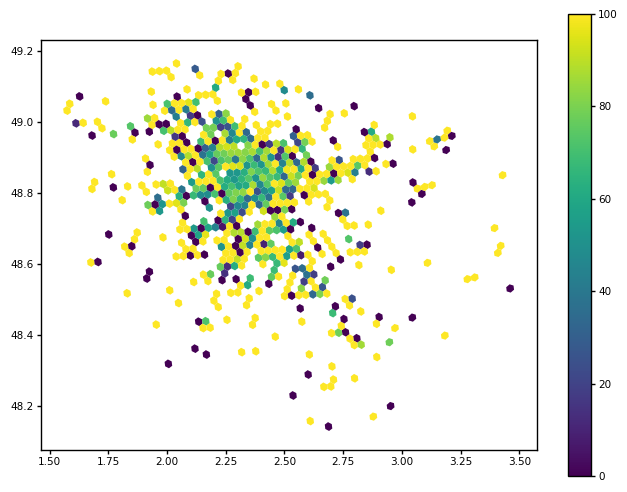

In [202]:
fig, ax = plt.subplots(figsize=(8, 6))
gdf_h3.plot(
    column="tc_non_zero",     # <-- column with values
    cmap="viridis",           # or "Reds", "coolwarm", etc.
    legend=True,
    ax=ax
)
plt.show()

In [203]:
gdf_h3.to_file('results/h3_s7_ak_tc.gpkg', driver='GPKG', layer='h3_s7_ak_tc')

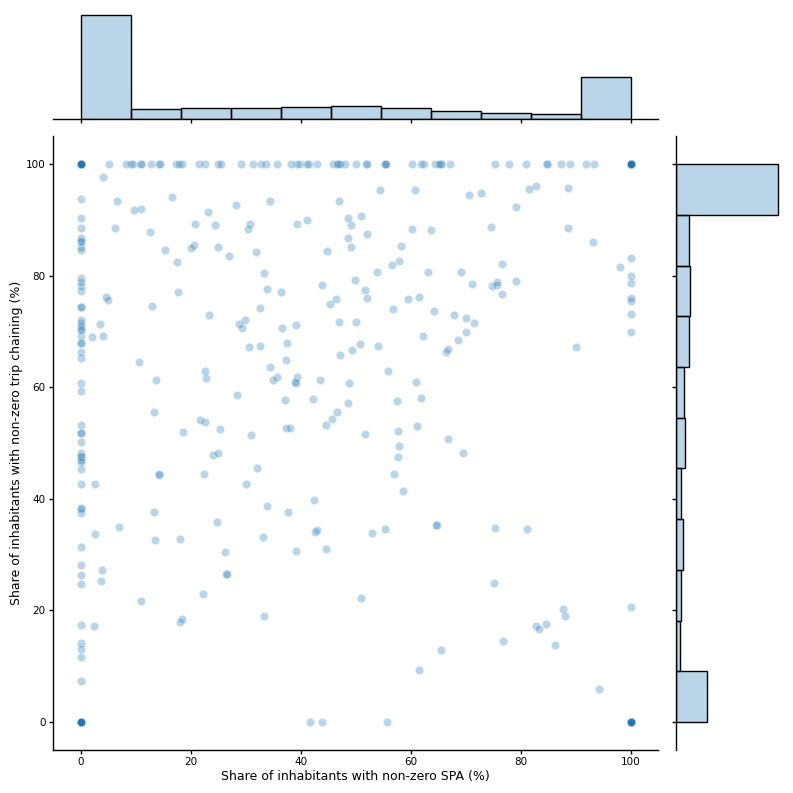

In [198]:
# Jointplot with scatter and KDE marginals
g = sns.jointplot(
    data=gdf_h3,
    x="ak_non_zero",
    y="tc_non_zero",
    kind="scatter",
    marginal_kws=dict(common_norm=False, fill=True, alpha=0.3),
    palette="Set1",
    height=8,
    alpha=0.3
)

# Set log-log axes
# g.ax_joint.set_xscale("log")
# g.ax_joint.set_yscale("log")

# Axis labels
g.set_axis_labels("Share of inhabitants with non-zero SPA (%)", "Share of inhabitants with non-zero trip chaining (%)")

plt.tight_layout()
plt.show()

In [92]:
df_res = df_filtered.groupby(['ak_cat', 'Household_type']).agg({
    'ID': 'count',  # Count of IDs
    'entropy_mm': 'mean',  # Mean of entropy_mm
    'activity_time_third': 'mean',  # Mean
    'access_h': 'mean',  # Mean of access_h
    'xs_total_hws': 'mean',
    'ak': 'mean',  # Mean of ak
    'trip_chaining_presence': 'sum'
}).reset_index().sort_values(by=['ak_cat', 'Household_type'])
df_res[df_res.Household_type == 2]

,ak_cat,Household_type,ID,entropy_mm,activity_time_third,access_h,xs_total_hws,ak,trip_chaining_presence
2,Non-zero,2,59,1.404114,148.129956,9559.194915,0.546639,3620.237288,49
9,Zero,2,175,1.302275,112.691542,5781.245714,0.374847,0.000000,137


In [ ]:
household_order = {
    'Living alone': 0,
    'In a couple without children': 1,
    'Single parent (divorced / separated / widowed)': 2,
    'Living with one or both parents': 3,
    'Not related to other household members': 4,
    'In a shared apartment (flat-sharing)': 5,
    'In a couple with child(ren)': 6,
    'Another family member in the household': 7
}